In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [3]:
path = "./data/tel_preprocessed_ver2.csv"
df = pd.read_csv(path)

print("shape:", df.shape)
print(df.head())
print(df.dtypes)
print('df.size:', df.size)

# 데이터 정렬 (id, year 기준)
df = df.sort_values(["id", "year"]).reset_index(drop=True)

shape: (34776, 14)
      id  gender  birth_year  mar  income  job  region  phone_usage_per_m  \
0  10002       1        1972    2       1    0       1                  3   
1  10002       1        1972    2       1    0       1                  4   
2  10002       1        1972    2       1    0       1                  6   
3  10002       1        1972    2       1    0       1                  4   
4  10002       1        1972    2       1    0       1                  4   

   mobile_bundle  telecom  year  telcom_changed churn_status_2  \
0              0        1  2017               0       SKT_stay   
1              1        1  2018               0       SKT_stay   
2              1        1  2019               0       SKT_stay   
3              1        2  2020               1    SKT_churned   
4              1        2  2021               0        KT_stay   

   churn_status_num_2  
0                   1  
1                   1  
2                   1  
3                  10  
4

In [4]:
# # churn_status_2 문자열에 'churned' 포함 → 이탈(1)
# df["y_churn"] = df["churn_status_2"].astype(str).str.contains("churned", case=False, na=False).astype(int)

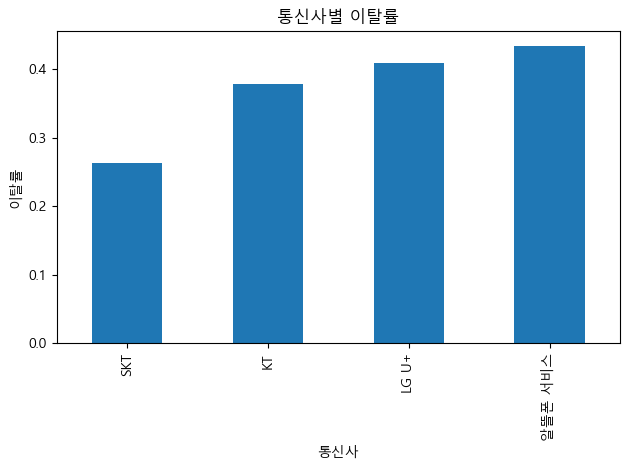

In [5]:
# 통신사별 이탈률(전체)
telecom_churn = df.groupby("telecom")["telcom_changed"].mean().sort_index()
telecom_map = {
    1: "SKT",
    2: "KT",
    3: "LG U+",
    4: "알뜰폰 서비스"
}
df["telecom_label"] = df["telecom"].map(telecom_map)
telecom_churn = df.groupby("telecom_label")["telcom_changed"].mean().sort_values()

plt.figure()
telecom_churn.plot(kind="bar")
plt.title("통신사별 이탈률")
plt.xlabel("통신사")
plt.ylabel("이탈률")
plt.tight_layout()
plt.show()


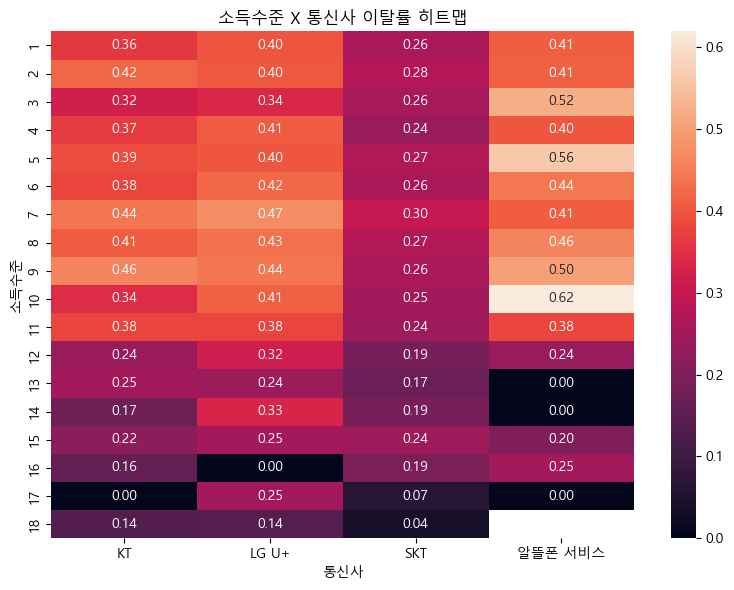

<Figure size 1000x500 with 0 Axes>

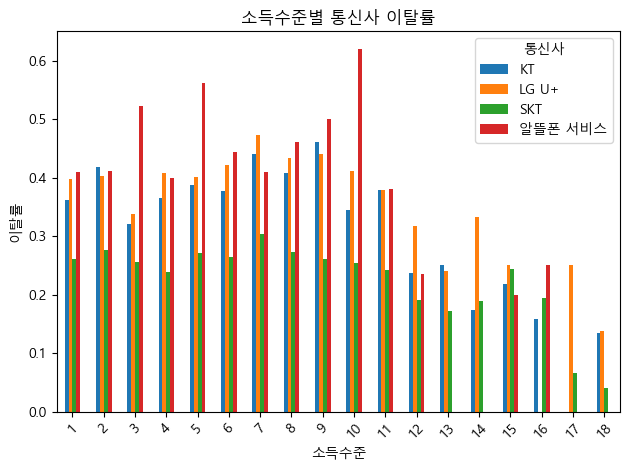

In [6]:
# [개인정보] 개인 월평균 소득
#   1	소득 없음
# 	2	50만 원 미만
# 	3	500100만 원 미만
# 	4	1000150만 원 미만
# 	5	1500200만 원 미만
# 	6	2000250만 원 미만
# 	7	2500300만 원 미만
# 	8	3000350만 원 미만
# 	9	3500400만 원 미만
# 	10	4000450만 원 미만
# 	11	4500500만 원 미만
# 	12	5000550만 원 미만
# 	13	5500600만 원 미만
# 	14	6000650만 원 미만
# 	15	6500700만 원 미만
# 	16	7000750만 원 미만
# 	17	7500800만 원 미만
# 	18	800만 원 이상

pivot_income = df.pivot_table(
    index="income",
    columns="telecom_label",
    values="telcom_changed",
    aggfunc="mean"
)

plt.figure(figsize=(8,6))

sns.heatmap(
    pivot_income,
    annot=True,
    fmt=".2f"
)

plt.title("소득수준 X 통신사 이탈률 히트맵")
plt.xlabel("통신사")
plt.ylabel("소득수준")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))

pivot_income.plot(kind="bar")

plt.title("소득수준별 통신사 이탈률")
plt.xlabel("소득수준")
plt.ylabel("이탈률")

plt.xticks(rotation=45)
plt.legend(title="통신사")

plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

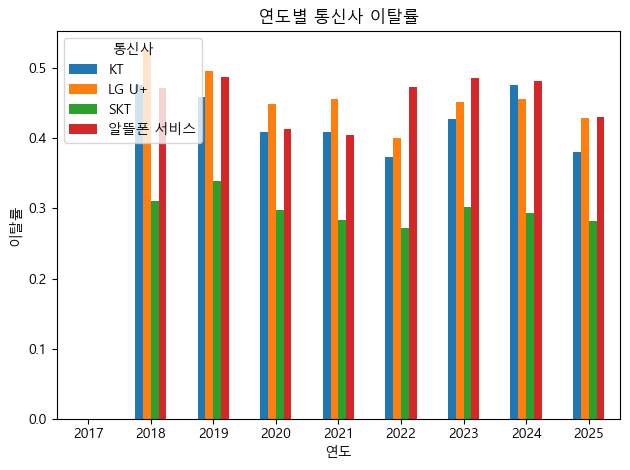

In [7]:
pivot_year = df.pivot_table(
    index="year",
    columns="telecom_label",
    values="telcom_changed",
    aggfunc="mean"
).sort_index()

plt.figure(figsize=(10,5))

pivot_year.plot(kind="bar")

plt.title("연도별 통신사 이탈률")
plt.xlabel("연도")
plt.ylabel("이탈률")

plt.xticks(rotation=0)
plt.legend(title="통신사")

plt.tight_layout()
plt.show()

In [8]:
print(df["year"].value_counts().sort_index())
print(df[df["year"]==2017].shape)
print(df[df["year"]==2017]["telcom_changed"].isna().sum())

year
2017    3864
2018    3864
2019    3864
2020    3864
2021    3864
2022    3864
2023    3864
2024    3864
2025    3864
Name: count, dtype: int64
(3864, 15)
0


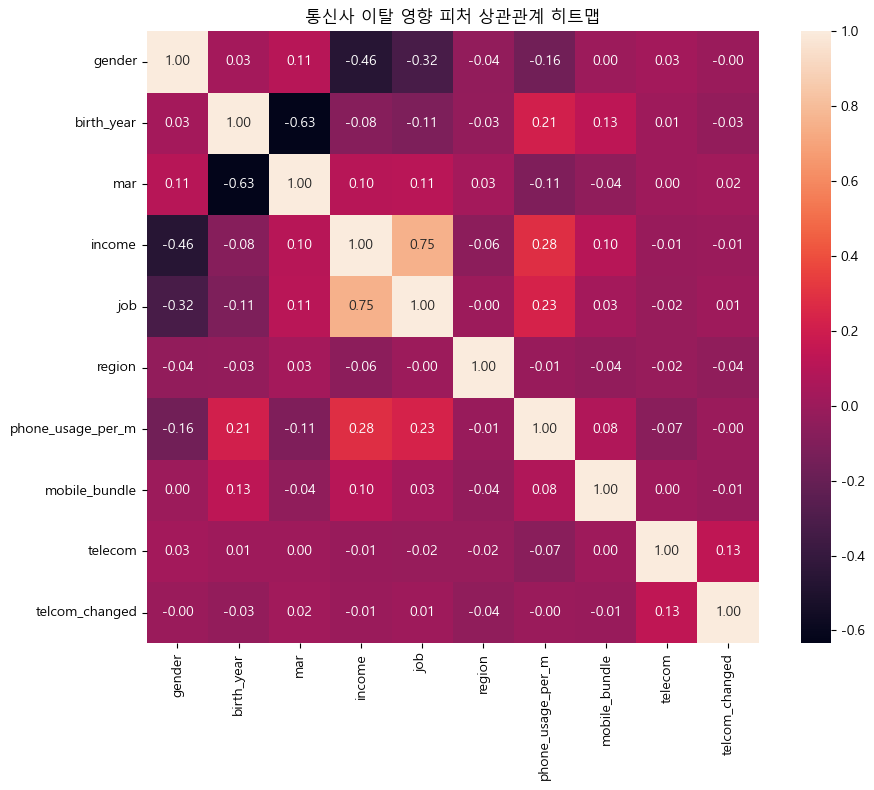

In [9]:

heat_cols = [
    "gender",
    "birth_year",
    "mar",
    "income",
    "job",
    "region",
    "phone_usage_per_m",
    "mobile_bundle",
    "telecom",
    "telcom_changed"
]

heat_df = df[heat_cols]

# 상관관계 계산
corr = heat_df.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    square=True
)

plt.title("통신사 이탈 영향 피처 상관관계 히트맵")

plt.tight_layout()
plt.show()

C:\Users\Playdata\AppData\Local\Temp\ipykernel_34452\2783765251.py:17: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


<Figure size 900x500 with 0 Axes>

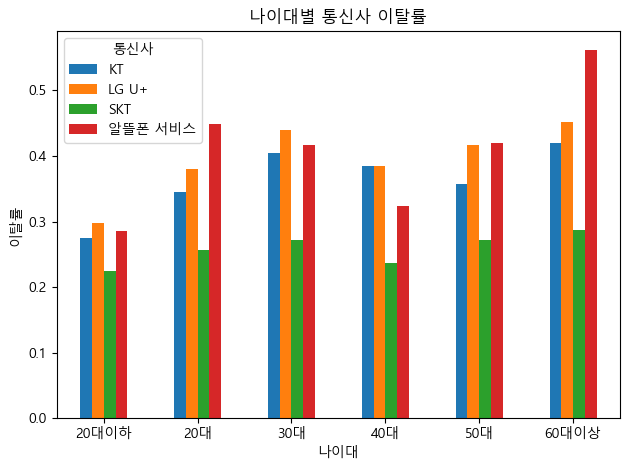

In [10]:
# 나이 계산
df["age"] = df["year"] - df["birth_year"]

bins = [0,20,30,40,50,60,100]
labels = ["20대이하","20대","30대","40대","50대","60대이상"]

df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels, right=False)

telecom_map = {
    1:"SKT",
    2:"KT",
    3:"LG U+",
    4:"알뜰폰 서비스"
}
df["telecom_label"] = df["telecom"].map(telecom_map)

pivot = df.pivot_table(
    index="age_group",
    columns="telecom_label",
    values="telcom_changed",
    aggfunc="mean"
)

# 그래프
plt.figure(figsize=(9,5))
pivot.plot(kind="bar")

plt.title("나이대별 통신사 이탈률")
plt.xlabel("나이대")
plt.ylabel("이탈률")

plt.xticks(rotation=0)
plt.legend(title="통신사")

plt.tight_layout()
plt.show()

C:\Users\Playdata\AppData\Local\Temp\ipykernel_34452\544431011.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


<Figure size 1200x600 with 0 Axes>

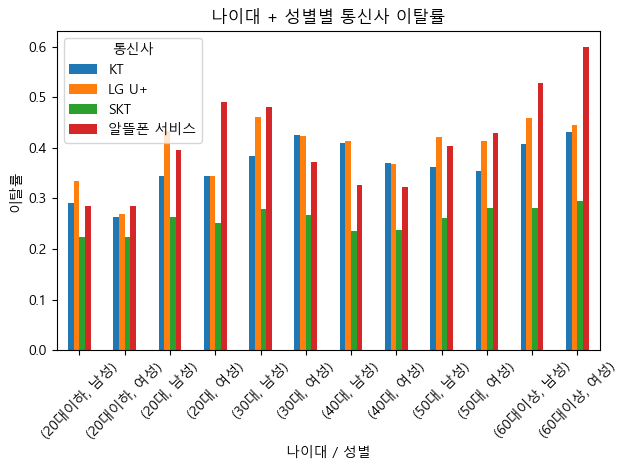

In [11]:
gender_map = {
    0: "남성",
    1: "여성"
}

df["gender_label"] = df["gender"].map(gender_map)

pivot = df.pivot_table(
    index=["age_group","gender_label"],
    columns="telecom_label",
    values="telcom_changed",
    aggfunc="mean"
)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(12,6))

pivot.plot(kind="bar")

plt.title("나이대 + 성별별 통신사 이탈률")
plt.xlabel("나이대 / 성별")
plt.ylabel("이탈률")

plt.xticks(rotation=45)
plt.legend(title="통신사")

plt.tight_layout()
plt.show()

In [12]:
df["income"].value_counts().sort_index()

income
1     10318
2      1225
3      1462
4      2170
5      3865
6      3918
7      4158
8      2594
9      2098
10      977
11      767
12      553
13      232
14      124
15       89
16       58
17       28
18      140
Name: count, dtype: int64

In [13]:
df.count()

id                    34776
gender                34776
birth_year            34776
mar                   34776
income                34776
job                   34776
region                34776
phone_usage_per_m     34776
mobile_bundle         34776
telecom               34776
year                  34776
telcom_changed        34776
churn_status_2        34776
churn_status_num_2    34776
telecom_label         34776
age                   34776
age_group             34776
gender_label          34776
dtype: int64

<Figure size 1000x500 with 0 Axes>

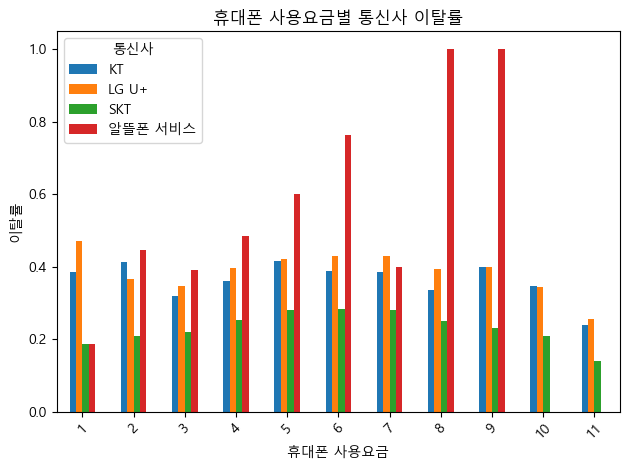

In [ ]:
# 휴대폰 사용요금 기준 eda
# [방송통신 서비스 가입 및 지출 현황] 월평균 휴대폰 이용 총 금액(리코드)
#   1	1만원 미만
# 	2	1만원 이상 0 2만원 미만
# 	3	2만원 이상 0 3만원 미만
# 	4	3만원 이상 0 4만원 미만
# 	5	4만원 이상 0 5만원 미만
# 	6	5만원 이상 0 6만원 미만
# 	7	6만원 이상 0 7만원 미만
# 	8	7만원 이상 0 8만원 미만
# 	9	8만원 이상 0 9만원 미만
# 	10	9만원 이상 0 10만원 미만
# 	11	10만원 이상
# 	9999	모름/무응답

pivot_income = df.pivot_table(
    index="phone_usage_per_m",
    columns="telecom_label",
    values="telcom_changed",
    aggfunc="mean"
)

plt.figure(figsize=(10,5))

pivot_income.plot(kind="bar")

plt.title("휴대폰 사용요금별 통신사 이탈률")
plt.xlabel("휴대폰 사용요금")
plt.ylabel("이탈률")

plt.xticks(rotation=45)
plt.legend(title="통신사")

plt.tight_layout()
plt.show()